Diabetes Health Indicators ML Project

This project predicts:
- Diabetes (Binary Classification)
- Diabetes Stage (Multiclass)
- Risk Score (Regression)

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/diabetes.csv")
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [2]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


CREATE TARGET VARIABLES

In [4]:
df.columns.tolist()

['age',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diabetes_stage',
 'diagnosed_diabetes']

handling missing values


In [5]:
df = df.fillna(df.mean(numeric_only=True))


Encode categorical columns

In [6]:
df = pd.get_dummies(df, drop_first=True)

EDA

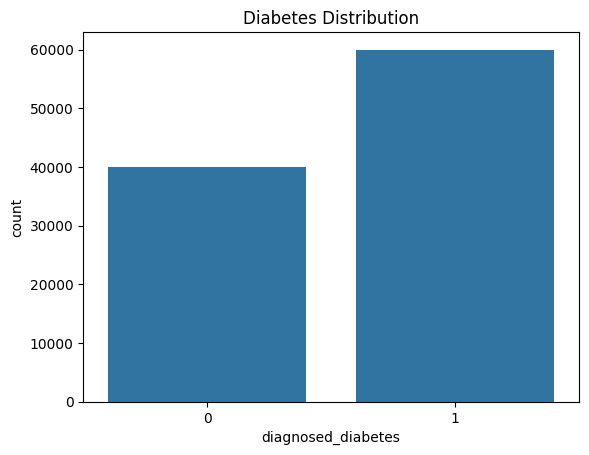

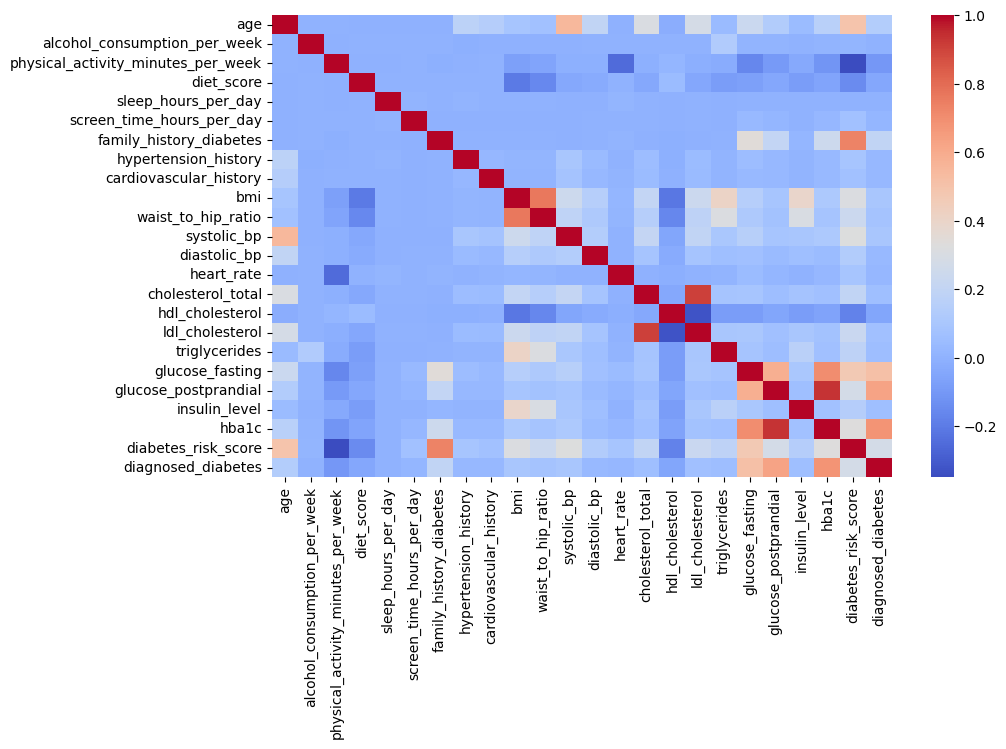

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Binary target
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

# Correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

DEFINE FEATURES & TARGETS

In [9]:
df.columns.tolist()


['age',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diagnosed_diabetes',
 'gender_Male',
 'gender_Other',
 'ethnicity_Black',
 'ethnicity_Hispanic',
 'ethnicity_Other',
 'ethnicity_White',
 'education_level_Highschool',
 'education_level_No formal',
 'education_level_Postgraduate',
 'income_level_Low',
 'income_level_Lower-Middle',
 'income_level_Middle',
 'income_level_Upper-Middle',
 'employment_status_Retired',
 'employment_status_Student',
 'employment_status_Unemployed',
 'smoking_status_Former',
 'smoking_status_Never',
 'diabetes_stage_No Diabetes',
 '

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/diabetes.csv")


In [2]:
y_binary = df["diagnosed_diabetes"]
y_multi = df["diabetes_stage"]
y_reg = df["diabetes_risk_score"]

Drop targets from features

In [3]:
X = df.drop(columns=[
    "diagnosed_diabetes",
    "diabetes_stage",
    "diabetes_risk_score"
])

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, stratify=y_binary, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.2, stratify=y_multi, random_state=42)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

MODELS

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic": LogisticRegression(),
    "Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train_b, y_train_b)
    preds = model.predict(X_test_b)
    
    print(name)
    print(classification_report(y_test_b, preds))

Logistic
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.90      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000

Tree
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000

KNN
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      8000
           1       0.81      0.82      0.82     12000

    accuracy                           0.78     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.78      0.78      0.78     20000

